# Home Exercise on Linear Regression
## Task Description
Implement a **linear regression model** using *gradient descent, Adam, any other optimization method* to optimize the parameters or closed-form solution. (You can use other variations of Linear Regression, such as **Lasso, Ridge, etc**, but you must implement them yourself.)

 
* You are only allowed to use computational libraries such as NumPy, Math, etc for implementing the model and training process.
  
* You must not use machine learning libraries or frameworks like scikit-learn, TensorFlow, PyTorch, etc. that provide pre-built models.

* For other tasks (e.g., data processing, visualization), you are free to use any library.

After implementing the model, use it to solve the following problem: _Housing Prices Competition for Kaggle Learn Users_

## Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, shutil

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [ ]:
#!kaggle competitions download -c home-data-for-ml-course

  0%|                                                | 0.00/386k [00:00<?, ?B/s]
100%|████████████████████████████████████████| 386k/386k [00:00<00:00, 26.6MB/s]


In [10]:
def moving_folder(path, des):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    try:
        shutil.move(path, des)
        print(f"Successfully moved folder '{os.path.basename(path)}' to '{des}'")
    except shutil.Error as e:
        print(f"There are errors. Try again!")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

In [11]:
path = "./home-data-for-ml-course.zip"
data_dir = "./data"

moving_folder(path, data_dir)

Successfully moved folder 'home-data-for-ml-course.zip' to './data'


In [12]:
import zipfile
def unzip_file(path, des, delete=True):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    with zipfile.ZipFile(path) as zipref:
        zipref.extractall(des)
        print(f"Extracted zipfile in {des}")
    if delete:
        os.remove(path)
        return

In [13]:
zip_path = os.path.join(data_dir, "home-data-for-ml-course.zip")
unzip_file(zip_path, des=data_dir, delete=True)

Extracted zipfile in ./data


In [14]:
for filename in os.listdir(data_dir):
    filepath = os.path.join(data_dir, filename)
    if os.path.isfile(filepath):
        if not filename.lower().endswith('.csv') and filename != "data_description.txt":
            os.remove(filepath)
            print(f"{filename} was deleted")
        else:
            print(f"Keep: {filename}")
    else:
        print(f"Keep subfolder: {filename}")
        
print("Cleaning completely!")

Keep: data_description.txt
Keep: sample_submission.csv
sample_submission.csv.gz was deleted
Keep: test.csv
test.csv.gz was deleted
Keep: train.csv
train.csv.gz was deleted
Cleaning completely!


## Load data into DataFrame

In [28]:
train_data = os.path.join(data_dir, "train.csv")
test_data = os.path.join(data_dir, "test.csv")

if os.path.exists(train_data) and os.path.exists(test_data):
    print("True")
    train_df = pd.read_csv(train_data)
    test_df = pd.read_csv(test_data)
    print(train_df.head(5))    
    print(train_df.info())


True
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        

In [29]:
# Check null values
print(train_df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [30]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Data Preprocessing

In [31]:
train_df = train_df.drop(["Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"], axis=1)
test_df = test_df.drop(["Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"], axis=1)


### Fill the missing values in numerical columns with the mean of that column

In [32]:
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.drop("SalePrice")

# Fill missing values in each numerical column with its own mean
for col in numerical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mean())
    test_df[col] = test_df[col].fillna(test_df[col].mean())

### Process the categorical columns

In [36]:
LE = LabelEncoder()
categorical_cols = train_df.select_dtypes(include=("object")).columns
for coll in categorical_cols:
    train_df[coll] = LE.fit_transform(train_df[coll])
    test_df[coll] = LE.transform(test_df[coll])


## Split the data into features and target variable

In [37]:
from sklearn.model_selection import train_test_split
X = train_df.drop("SalePrice", axis = 1)
y = train_df["SalePrice"]

## Split train and test sets

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state =42)
print(X_train[:5])
print(y_train[:5])

      Id  MSSubClass  MSZoning  LotFrontage  LotArea  Street  LotShape  \
736  737          90         3    60.000000     8544       1         3   
898  899          20         3   100.000000    12919       1         0   
682  683         120         3    70.049958     2887       1         3   
990  991          60         3    82.000000     9452       1         3   
718  719          60         3    96.000000    10542       1         3   

     LandContour  Utilities  LotConfig  ...  OpenPorchSF  EnclosedPorch  \
736            3          0          4  ...            0              0   
898            3          0          4  ...           67              0   
682            1          0          4  ...            0              0   
990            3          0          4  ...           70              0   
718            3          0          4  ...          154            216   

     3SsnPorch  ScreenPorch  PoolArea  MiscVal  MoSold  YrSold  SaleType  \
736          0            0 

## Define the Linear Regression model

In [ ]:
from typing import Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Optional

class LinearRegression:   
    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000, 
                 method: str = 'gradient_descent', regularization: Optional[str] = None,
                 lambda_reg: float = 0.1, epsilon: float = 1e-8):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.method = method
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.epsilon = epsilon
        
        self.weights = None
        self.bias = None
        self.cost_history = []
        
        self.m_w = None
        self.v_w = None
        self.m_b = None
        self.v_b = None
        self.beta1 = 0.9
        self.beta2 = 0.999
        
    def _initialize_parameters(self, n_features: int):
        self.weights = np.random.randn(n_features, 1) * 0.01
        self.bias = 0
        
        # Initialize Adam parameters
        if self.method == 'adam':
            self.m_w = np.zeros((n_features, 1))
            self.v_w = np.zeros((n_features, 1))
            self.m_b = 0
            self.v_b = 0
    
    def _compute_predictions(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias
    
    def _compute_cost(self, X: np.ndarray, y: np.ndarray) -> float:
        m = X.shape[0]
        predictions = self._compute_predictions(X)
        mse_cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
        
        reg_cost = 0
        if self.regularization == 'ridge':
            # L2 regularization: lambda * sum(w^2)
            reg_cost = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)
        elif self.regularization == 'lasso':
            # L1 regularization: lambda * sum(|w|)
            reg_cost = (self.lambda_reg / m) * np.sum(np.abs(self.weights))
        
        return mse_cost + reg_cost
    
    def _compute_gradients(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Compute gradients for weights and bias.
        
        dw = (1/m) * X.T @ (y_pred - y) + regularization_gradient
        db = (1/m) * sum(y_pred - y)
        """
        m = X.shape[0]
        predictions = self._compute_predictions(X)
        error = predictions - y
        
        # Gradient for weights
        dw = (1 / m) * (X.T @ error)
        
        # Add regularization gradient
        if self.regularization == 'ridge':
            # Ridge gradient: lambda * w
            dw += (self.lambda_reg / m) * self.weights
        elif self.regularization == 'lasso':
            # Lasso gradient: lambda * sign(w)
            dw += (self.lambda_reg / m) * np.sign(self.weights)
        
        # Gradient for bias
        db = (1 / m) * np.sum(error)
        
        return dw, db
    
    def _gradient_descent_step(self, X: np.ndarray, y: np.ndarray):
        dw, db = self._compute_gradients(X, y)
        
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
    
    def _adam_step(self, X: np.ndarray, y: np.ndarray, t: int):
        dw, db = self._compute_gradients(X, y)
        
        # Update first moment (mean of gradients)
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        
        # Update second moment (uncentered variance of gradients)
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (dw ** 2)
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (db ** 2)
        
        # Bias correction
        m_w_corrected = self.m_w / (1 - self.beta1 ** t)
        m_b_corrected = self.m_b / (1 - self.beta1 ** t)
        v_w_corrected = self.v_w / (1 - self.beta2 ** t)
        v_b_corrected = self.v_b / (1 - self.beta2 ** t)
        
        # Update parameters
        self.weights -= self.learning_rate * m_w_corrected / (np.sqrt(v_w_corrected) + self.epsilon)
        self.bias -= self.learning_rate * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)
    
    def _closed_form_solution(self, X: np.ndarray, y: np.ndarray):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        
        if self.regularization == 'ridge':
            # Ridge regression closed form
            identity = np.eye(X_b.shape[1])
            identity[0, 0] = 0  # Don't regularize bias term
            theta = np.linalg.pinv(X_b.T @ X_b + self.lambda_reg * identity) @ X_b.T @ y
        else:
            # Standard least squares
            theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        self.bias = theta[0, 0]
        self.weights = theta[1:].reshape(-1, 1)
    
    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True):
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        m, n = X.shape
        
        if self.method == 'closed_form':
            if self.regularization == 'lasso':
                print("Warning: Closed-form solution not available for Lasso. Using gradient descent instead.")
                self.method = 'gradient_descent'
                self._initialize_parameters(n)
            else:
                self._closed_form_solution(X, y)
                cost = self._compute_cost(X, y)
                self.cost_history = [cost]
                if verbose:
                    print(f"Closed-form solution computed. Final cost: {cost:.4f}")
                return
        self._initialize_parameters(n)
        
        # Training loop
        for i in range(1, self.n_iterations + 1):
            if self.method == 'gradient_descent':
                self._gradient_descent_step(X, y)
            elif self.method == 'adam':
                self._adam_step(X, y, i)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            cost = self._compute_cost(X, y)
            self.cost_history.append(cost)

            if verbose and i % (self.n_iterations // 10) == 0:
                print(f"Iteration {i}/{self.n_iterations}, Cost: {cost:.4f}")
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.weights is None:
            raise ValueError("Model has not been trained yet. Call fit() first.")
        
        predictions = self._compute_predictions(X)
        return predictions.flatten()
    
    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    def plot_cost_history(self):
        """Plot the cost history during training."""
        plt.figure(figsize=(10, 6))
        plt.plot(self.cost_history)
        plt.xlabel('Iteration')
        plt.ylabel('Cost')
        plt.title('Cost Function History')
        plt.grid(True)
        plt.show()

def preprocess_data(X_train, X_test, y_train, y_test):

    if 'Id' in X_train.columns:
        X_train = X_train.drop('Id', axis=1)
        X_test = X_test.drop('Id', axis=1)
    
    X_train_np = X_train.values.astype(np.float64)
    X_test_np = X_test.values.astype(np.float64)
    y_train_np = y_train.values.astype(np.float64)
    y_test_np = y_test.values.astype(np.float64)

    mean = np.mean(X_train_np, axis=0)
    std = np.std(X_train_np, axis=0)
    
    std[std == 0] = 1
    
    X_train_normalized = (X_train_np - mean) / std
    X_test_normalized = (X_test_np - mean) / std
    
    return X_train_normalized, X_test_normalized, y_train_np, y_test_np

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    # Preprocess data
    X_train_norm, X_test_norm, y_train_np, y_test_np = preprocess_data(
        X_train, X_test, y_train, y_test
    )
    
    models = {
        'Gradient Descent': LinearRegression(
            learning_rate=0.1, 
            n_iterations=1000, 
            method='gradient_descent'
        ),
        'Adam Optimizer': LinearRegression(
            learning_rate=0.1, 
            n_iterations=1000, 
            method='adam'
        ),
        'Closed Form': LinearRegression(
            method='closed_form'
        ),
        'Ridge Regression': LinearRegression(
            learning_rate=0.1, 
            n_iterations=1000, 
            method='gradient_descent',
            regularization='ridge',
            lambda_reg=1.0
        ),
        'Lasso Regression': LinearRegression(
            learning_rate=0.1, 
            n_iterations=1000, 
            method='gradient_descent',
            regularization='lasso',
            lambda_reg=0.1
        )
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\n{'='*60}")
        print(f"Training {name}")
        print('='*60)
        
        model.fit(X_train_norm, y_train_np, verbose=True)
        
        # Evaluate
        train_score = model.score(X_train_norm, y_train_np)
        test_score = model.score(X_test_norm, y_test_np)
        
        # Calculate RMSE
        train_pred = model.predict(X_train_norm)
        test_pred = model.predict(X_test_norm)
        train_rmse = np.sqrt(np.mean((y_train_np - train_pred) ** 2))
        test_rmse = np.sqrt(np.mean((y_test_np - test_pred) ** 2))
        
        results[name] = {
            'Train R²': train_score,
            'Test R²': test_score,
            'Train RMSE': train_rmse,
            'Test RMSE': test_rmse
        }
        
        print(f"\nResults:")
        print(f"Train R²: {train_score:.4f}")
        print(f"Test R²: {test_score:.4f}")
        print(f"Train RMSE: ${train_rmse:,.2f}")
        print(f"Test RMSE: ${test_rmse:,.2f}")
    
    # Display comparison
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print('='*60)
    results_df = pd.DataFrame(results).T
    print(results_df)
    
    return models, results

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_single_model(model, X_train_norm, X_test_norm, y_train_np, y_test_np):
    """
    Visualize kết quả của 1 model duy nhất
    
    Parameters:
    -----------
    model : trained LinearRegression model
    X_train_norm, X_test_norm : normalized features
    y_train_np, y_test_np : target values
    """
    
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    train_pred = model.predict(X_train_norm)
    test_pred = model.predict(X_test_norm)
    
    train_rmse = np.sqrt(np.mean((y_train_np - train_pred) ** 2))
    test_rmse = np.sqrt(np.mean((y_test_np - test_pred) ** 2))
    
    train_r2 = 1 - (np.sum((y_train_np - train_pred) ** 2) / np.sum((y_train_np - np.mean(y_train_np)) ** 2))
    test_r2 = 1 - (np.sum((y_test_np - test_pred) ** 2) / np.sum((y_test_np - np.mean(y_test_np)) ** 2))
    
    train_mape = np.mean(np.abs((y_train_np - train_pred) / y_train_np)) * 100
    test_mape = np.mean(np.abs((y_test_np - test_pred) / y_test_np)) * 100
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, 0])
    metrics_data = {
        'Metric': ['R² Score', 'RMSE ($)', 'MAPE (%)'],
        'Train': [train_r2, train_rmse, train_mape],
        'Test': [test_r2, test_rmse, test_mape]
    }
    metrics_df = pd.DataFrame(metrics_data)
    
    x = np.arange(len(metrics_df['Metric']))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, metrics_df['Train'], width, label='Train', alpha=0.8)
    bars2 = ax1.bar(x + width/2, metrics_df['Test'], width, label='Test', alpha=0.8)
    
    ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_df['Metric'])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    for i, (t, v) in enumerate(zip(metrics_df['Train'], metrics_df['Test'])):
        ax1.text(i - width/2, t, f'{t:.2f}', ha='center', va='bottom', fontsize=9)
        ax1.text(i + width/2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax2 = fig.add_subplot(gs[0, 1])
    if len(model.cost_history) > 1:
        ax2.plot(model.cost_history, linewidth=2, color='blue')
        ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cost', fontsize=12, fontweight='bold')
        ax2.set_title('Training Cost History', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No cost history\n(Closed-form solution)', 
                ha='center', va='center', fontsize=12, transform=ax2.transAxes)
        ax2.set_title('Training Cost History', fontsize=14, fontweight='bold')
    
    ax3 = fig.add_subplot(gs[0, 2])
    overfitting_gap = train_r2 - test_r2
    colors_gap = ['green' if overfitting_gap < 0.05 else 'orange' if overfitting_gap < 0.1 else 'red']
    
    ax3.bar(['Train R²', 'Test R²', 'Gap'], [train_r2, test_r2, overfitting_gap], 
            color=['skyblue', 'coral', colors_gap[0]], alpha=0.8)
    ax3.set_ylabel('R² Score / Gap', fontsize=12, fontweight='bold')
    ax3.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    for i, v in enumerate([train_r2, test_r2, overfitting_gap]):
        ax3.text(i, v, f'{v:.4f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)
    
    ax4 = fig.add_subplot(gs[1, :2])
    sns.scatterplot(x=y_train_np, y=train_pred, alpha=0.6, ax=ax4, s=50, label='Train')
    ax4.plot([y_train_np.min(), y_train_np.max()], 
             [y_train_np.min(), y_train_np.max()], 
             'r--', lw=2, label='Perfect Prediction')
    ax4.set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
    ax4.set_title(f'Training Set Predictions (R² = {train_r2:.4f})', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    ax5 = fig.add_subplot(gs[1, 2])
    sns.scatterplot(x=y_test_np, y=test_pred, alpha=0.6, ax=ax5, s=50, color='orange', label='Test')
    ax5.plot([y_test_np.min(), y_test_np.max()], 
             [y_test_np.min(), y_test_np.max()], 
             'r--', lw=2, label='Perfect Prediction')
    ax5.set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
    ax5.set_title(f'Test Set Predictions (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    train_residuals = y_train_np - train_pred
    test_residuals = y_test_np - test_pred
    
    ax6 = fig.add_subplot(gs[2, 0])
    sns.scatterplot(x=train_pred, y=train_residuals, alpha=0.6, ax=ax6)
    ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax6.set_xlabel('Predicted Price ($)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
    ax6.set_title('Residual Plot - Train', fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    ax7 = fig.add_subplot(gs[2, 1])
    sns.scatterplot(x=test_pred, y=test_residuals, alpha=0.6, ax=ax7, color='orange')
    ax7.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax7.set_xlabel('Predicted Price ($)', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
    ax7.set_title('Residual Plot - Test', fontsize=14, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    ax8 = fig.add_subplot(gs[2, 2])
    sns.histplot(train_residuals, kde=True, ax=ax8, bins=30, color='skyblue', label='Train', alpha=0.5)
    sns.histplot(test_residuals, kde=True, ax=ax8, bins=30, color='coral', label='Test', alpha=0.5)
    ax8.set_xlabel('Residuals ($)', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax8.set_title('Residual Distribution', fontsize=14, fontweight='bold')
    ax8.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    plt.suptitle('Linear Regression Model - Comprehensive Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"MODEL PERFORMANCE SUMMARY")
    print(f"\nTraining Set:")
    print(f"   R² Score:  {train_r2:.4f}")
    print(f"   RMSE:      ${train_rmse:,.2f}")
    print(f"   MAPE:      {train_mape:.2f}%")
    print(f"\nTest Set:")
    print(f"   R² Score:  {test_r2:.4f}")
    print(f"   RMSE:      ${test_rmse:,.2f}")
    print(f"   MAPE:      {test_mape:.2f}%")
    print(f"\nOverfitting Analysis:")
    print(f"   R² Gap:    {overfitting_gap:.4f}")
    if overfitting_gap < 0.05:
        print(f"   Status: Excellent (minimal overfitting)")
    elif overfitting_gap < 0.1:
        print(f"   Status: Acceptable (some overfitting)")
    else:
        print(f"   Status: High overfitting (need more regularization)")
    
    print(f"\nResidual Analysis:")
    print(f"   Train Mean Residual:  ${np.mean(train_residuals):,.2f}")
    print(f"   Test Mean Residual:   ${np.mean(test_residuals):,.2f}")
    print(f"   Train Std Residual:   ${np.std(train_residuals):,.2f}")
    print(f"   Test Std Residual:    ${np.std(test_residuals):,.2f}")
    
    return {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mape': train_mape,
        'test_mape': test_mape,
        'overfitting_gap': overfitting_gap
    }

In [ ]:
def simple_grid_search(X_train, X_test, y_train, y_test, LinearRegression):
    # Preprocess data
    print("Preprocessing data...")
    if 'Id' in X_train.columns:
        X_train = X_train.drop('Id', axis=1)
        X_test = X_test.drop('Id', axis=1)
    
    X_train_np = X_train.values.astype(np.float64)
    X_test_np = X_test.values.astype(np.float64)
    y_train_np = y_train.values.astype(np.float64)
    y_test_np = y_test.values.astype(np.float64)
    
    # Normalize
    mean = np.mean(X_train_np, axis=0)
    std = np.std(X_train_np, axis=0)
    std[std == 0] = 1
    
    X_train_norm = (X_train_np - mean) / std
    X_test_norm = (X_test_np - mean) / std
    
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
        'lambda_reg': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        'n_iterations': [1000, 2000, 3000]
    }

    print(f"Sum of combinations: {len(param_grid['learning_rate']) * len(param_grid['lambda_reg']) * len(param_grid['n_iterations'])}")
    print(f"Learning rates: {param_grid['learning_rate']}")
    print(f"Lambda (regularization): {param_grid['lambda_reg']}")
    print(f"Iterations: {param_grid['n_iterations']}")
    
    # Store results
    results = []
    best_score = -np.inf
    best_model = None
    best_params = None
    
    total_combinations = (len(param_grid['learning_rate']) * 
                         len(param_grid['lambda_reg']) * 
                         len(param_grid['n_iterations']))
    current = 0
    
    # Grid search
    for lr in param_grid['learning_rate']:
        for lam in param_grid['lambda_reg']:
            for n_iter in param_grid['n_iterations']:
                current += 1
                
                print(f"\n[{current}/{total_combinations}] Testing: lr={lr}, lambda={lam}, iter={n_iter}")
                model = LinearRegression(
                    learning_rate=lr,
                    n_iterations=n_iter,
                    method='gradient_descent',
                    regularization='ridge',
                    lambda_reg=lam
                )
                
                try:
                    model.fit(X_train_norm, y_train_np, verbose=False)
                    
                    # Evaluate on train set
                    train_pred = model.predict(X_train_norm)
                    train_rmse = np.sqrt(np.mean((y_train_np - train_pred) ** 2))
                    train_r2 = 1 - (np.sum((y_train_np - train_pred) ** 2) / 
                                   np.sum((y_train_np - np.mean(y_train_np)) ** 2))
                    
                    # Evaluate on test set
                    test_pred = model.predict(X_test_norm)
                    test_rmse = np.sqrt(np.mean((y_test_np - test_pred) ** 2))
                    test_r2 = 1 - (np.sum((y_test_np - test_pred) ** 2) / 
                                  np.sum((y_test_np - np.mean(y_test_np)) ** 2))
                    
                    # Calculate MAPE
                    train_mape = np.mean(np.abs((y_train_np - train_pred) / y_train_np)) * 100
                    test_mape = np.mean(np.abs((y_test_np - test_pred) / y_test_np)) * 100
                    
                    # Overfitting gap
                    r2_gap = train_r2 - test_r2
                    
                    print(f"   Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, Gap={r2_gap:.4f}")
                    print(f"   Train RMSE=${train_rmse:,.0f}, Test RMSE=${test_rmse:,.0f}")
                    
                    # Store results
                    results.append({
                        'learning_rate': lr,
                        'lambda_reg': lam,
                        'n_iterations': n_iter,
                        'train_r2': train_r2,
                        'test_r2': test_r2,
                        'train_rmse': train_rmse,
                        'test_rmse': test_rmse,
                        'train_mape': train_mape,
                        'test_mape': test_mape,
                        'r2_gap': r2_gap,
                        'final_cost': model.cost_history[-1] if model.cost_history else np.nan
                    })
                    
                    # Track best model (based on test R²)
                    if test_r2 > best_score:
                        best_score = test_r2
                        best_model = model
                        best_params = {
                            'learning_rate': lr,
                            'lambda_reg': lam,
                            'n_iterations': n_iter
                        }
                        print(f"   ✨ NEW BEST! Test R²={test_r2:.4f}")
                
                except Exception as e:
                    print(f"   ❌ ERROR: {str(e)}")
                    continue
    
    results_df = pd.DataFrame(results)
    
    # Display best results
    print("\n" + "="*80)
    print("🏆 BEST MODEL FOUND")
    print("="*80)
    print(f"Learning Rate: {best_params['learning_rate']}")
    print(f"Lambda (Regularization): {best_params['lambda_reg']}")
    print(f"Iterations: {best_params['n_iterations']}")
    print(f"\nPerformance:")
    best_row = results_df[
        (results_df['learning_rate'] == best_params['learning_rate']) &
        (results_df['lambda_reg'] == best_params['lambda_reg']) &
        (results_df['n_iterations'] == best_params['n_iterations'])
    ].iloc[0]
    print(f"  Train R²: {best_row['train_r2']:.4f}")
    print(f"  Test R²: {best_row['test_r2']:.4f}")
    print(f"  Train RMSE: ${best_row['train_rmse']:,.2f}")
    print(f"  Test RMSE: ${best_row['test_rmse']:,.2f}")
    print(f"  Overfitting Gap: {best_row['r2_gap']:.4f}")
    
    return best_model, best_params, results_df, (X_train_norm, X_test_norm, y_train_np, y_test_np)


In [54]:
best_model, best_params, results_df, data = simple_grid_search(
    X_train, X_test, y_train, y_test, LinearRegression
)

Preprocessing data...
Sum of combinations: 90
Learning rates: [0.01, 0.05, 0.1, 0.2, 0.5]
Lambda (regularization): [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
Iterations: [1000, 2000, 3000]

[1/90] Testing: lr=0.01, lambda=0.01, iter=1000
   Train R²=0.8460, Test R²=0.8883, Gap=-0.0423
   Train RMSE=$31,270, Test RMSE=$24,772
   ✨ NEW BEST! Test R²=0.8883

[2/90] Testing: lr=0.01, lambda=0.01, iter=2000
   Train R²=0.8462, Test R²=0.8894, Gap=-0.0432
   Train RMSE=$31,245, Test RMSE=$24,649
   ✨ NEW BEST! Test R²=0.8894

[3/90] Testing: lr=0.01, lambda=0.01, iter=3000
   Train R²=0.8462, Test R²=0.8898, Gap=-0.0436
   Train RMSE=$31,243, Test RMSE=$24,607
   ✨ NEW BEST! Test R²=0.8898

[4/90] Testing: lr=0.01, lambda=0.1, iter=1000
   Train R²=0.8460, Test R²=0.8883, Gap=-0.0424
   Train RMSE=$31,270, Test RMSE=$24,771

[5/90] Testing: lr=0.01, lambda=0.1, iter=2000
   Train R²=0.8462, Test R²=0.8894, Gap=-0.0432
   Train RMSE=$31,245, Test RMSE=$24,649

[6/90] Testing: lr=0.01, lambda=0.1, iter=

/home/dikhang_hcmut/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_5304/3706419841.py:72: RuntimeWarning: overflow encountered in square
  mse_cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
/tmp/ipykernel_5304/3706419841.py:78: RuntimeWarning: overflow encountered in square
  reg_cost = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)
/tmp/ipykernel_5304/3706419841.py:97: RuntimeWarning: invalid value encountered in matmul
  dw = (1 / m) * (X.T @ error)
/home/dikhang_hcmut/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_5304/3706419841.py:116: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.learning_rate * dw


   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[75/90] Testing: lr=0.5, lambda=0.01, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[76/90] Testing: lr=0.5, lambda=0.1, iter=1000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[77/90] Testing: lr=0.5, lambda=0.1, iter=2000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[78/90] Testing: lr=0.5, lambda=0.1, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[79/90] Testing: lr=0.5, lambda=0.5, iter=1000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[80/90] Testing: lr=0.5, lambda=0.5, iter=2000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[81/90] Testing: lr=0.5, lambda=0.5, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[82/90] Testing: lr=0.5, lambda=1.0, iter=1000
   Train R²=nan, Test R²=nan, G

/tmp/ipykernel_5304/3706419841.py:62: RuntimeWarning: invalid value encountered in matmul
  return X @ self.weights + self.bias


   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[84/90] Testing: lr=0.5, lambda=1.0, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[85/90] Testing: lr=0.5, lambda=5.0, iter=1000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[86/90] Testing: lr=0.5, lambda=5.0, iter=2000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[87/90] Testing: lr=0.5, lambda=5.0, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[88/90] Testing: lr=0.5, lambda=10.0, iter=1000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[89/90] Testing: lr=0.5, lambda=10.0, iter=2000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

[90/90] Testing: lr=0.5, lambda=10.0, iter=3000
   Train R²=nan, Test R²=nan, Gap=nan
   Train RMSE=$nan, Test RMSE=$nan

🏆 BEST MODEL FOUND
Learning Rate: 0.1
Lambda (Regularization): 10.0
Iteratio

In [55]:
X_train_norm, X_test_norm, y_train_np, y_test_np = data
predictions = best_model.predict(X_test_norm)

In [56]:
final_model = LinearRegression(
    learning_rate=best_params['learning_rate'],
    n_iterations=best_params['n_iterations'],
    method='gradient_descent',
    regularization='ridge',
    lambda_reg=best_params['lambda_reg']
)
final_model.fit(X_train_norm, y_train_np)

Iteration 300/3000, Cost: 492162197.2041
Iteration 600/3000, Cost: 492153850.7334
Iteration 900/3000, Cost: 492153830.1064
Iteration 1200/3000, Cost: 492153830.0439
Iteration 1500/3000, Cost: 492153830.0437
Iteration 1800/3000, Cost: 492153830.0437
Iteration 2100/3000, Cost: 492153830.0437
Iteration 2400/3000, Cost: 492153830.0437
Iteration 2700/3000, Cost: 492153830.0437
Iteration 3000/3000, Cost: 492153830.0437


In [57]:
test_predictions = best_model.predict(X_test_norm)
results_comparison = pd.DataFrame({
    'Actual': y_test_np,
    'Predicted': test_predictions,
    'Error': y_test_np - test_predictions,
    'Error_Percent': ((y_test_np - test_predictions) / y_test_np) * 100
})
print(results_comparison.head(10))

     Actual      Predicted         Error  Error_Percent
0  154500.0  149954.417626   4545.582374       2.942125
1  325000.0  332514.218491  -7514.218491      -2.312067
2  115000.0  113821.537414   1178.462586       1.024750
3  159000.0  179517.013095 -20517.013095     -12.903782
4  315500.0  316727.932922  -1227.932922      -0.389202
5   75500.0   67733.326370   7766.673630      10.286985
6  311500.0  236264.509275  75235.490725      24.152645
7  146000.0  144210.618650   1789.381350       1.225604
8   84500.0   71155.442616  13344.557384      15.792376
9  135500.0  147169.032592 -11669.032592      -8.611832


## Visualize the results

/tmp/ipykernel_5304/3725352039.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


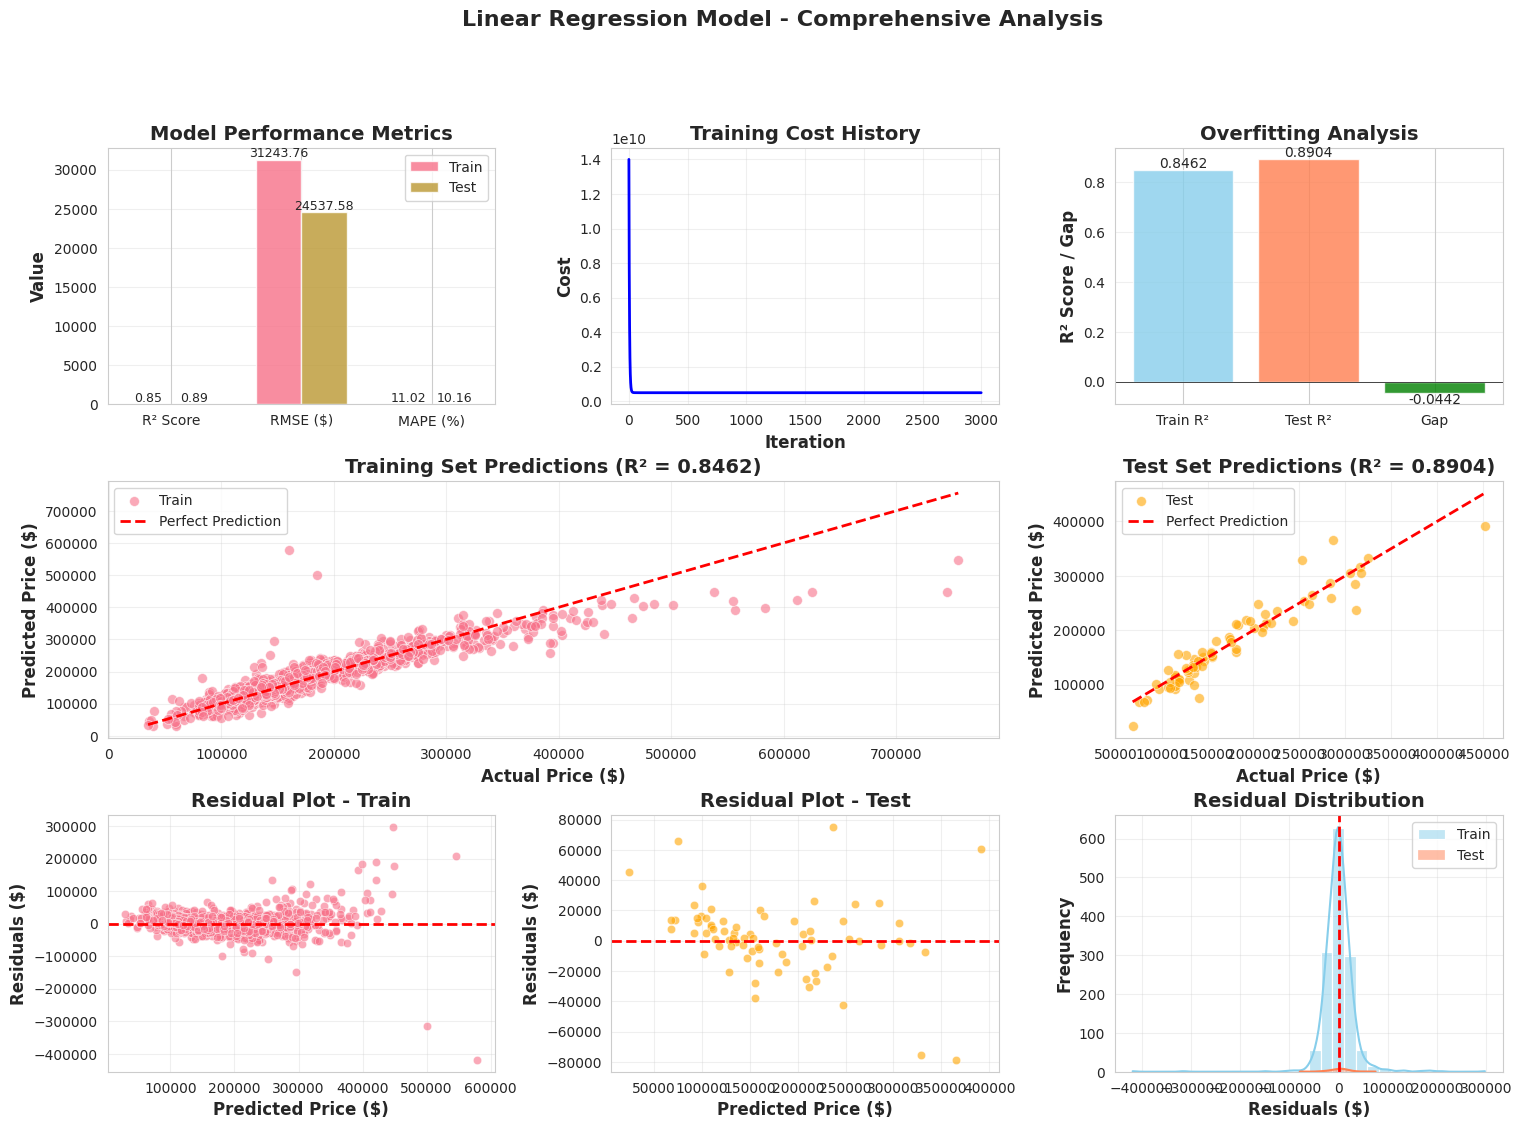

MODEL PERFORMANCE SUMMARY

Training Set:
   R² Score:  0.8462
   RMSE:      $31,243.76
   MAPE:      11.02%

Test Set:
   R² Score:  0.8904
   RMSE:      $24,537.58
   MAPE:      10.16%

Overfitting Analysis:
   R² Gap:    -0.0442
   Status: Excellent (minimal overfitting)

Residual Analysis:
   Train Mean Residual:  $0.00
   Test Mean Residual:   $1,721.50
   Train Std Residual:   $31,243.76
   Test Std Residual:    $24,477.12


In [60]:
results = visualize_single_model(best_model, X_train_norm, X_test_norm, y_train_np, y_test_np)

In [49]:
# Save best model parameters (weights)
np.save('best_model_weights.npy', best_model.weights)
np.save('best_model_bias.npy', best_model.bias)
print("Saved the best model parameter")

Saved the best model parameter


In [61]:
def submit_to_kaggle(best_model, test_df, train_mean, train_std, output_file='submission.csv'):
    print(f"\n📋 Test data shape: {test_df.shape}")
    print(f"📋 Columns: {test_df.columns.tolist()[:10]}...")
    
    test_ids = test_df['Id'].values
    print(f"✅ Extracted {len(test_ids)} test IDs")
    
    X_test_kaggle = test_df.drop('Id', axis=1)
    print(f"✅ Features shape: {X_test_kaggle.shape}")
    
    X_test_kaggle_np = X_test_kaggle.values.astype(np.float64)
    
    X_test_kaggle_norm = (X_test_kaggle_np - train_mean) / train_std
    print(f"✅ Normalized test features")
    
    predictions = best_model.predict(X_test_kaggle_norm)
    print(f"✅ Generated {len(predictions)} predictions")
    
    predictions = np.clip(predictions, 0, None)
    print(f"✅ Clipped negative predictions (if any)")
    
    submission = pd.DataFrame({
        'Id': test_ids,
        'SalePrice': predictions
    })
    
    submission.to_csv(output_file, index=False)
    
    print(f"\n{'='*70}")
    print(f"✅ FILE SUBMISSION ĐÃ ĐƯỢC TẠO: {output_file}")
    print(f"{'='*70}")
    
    print(f"\n📊 STATISTICS:")
    print(f"   Số predictions:    {len(submission)}")
    print(f"   Min price:         ${submission['SalePrice'].min():,.2f}")
    print(f"   Max price:         ${submission['SalePrice'].max():,.2f}")
    print(f"   Mean price:        ${submission['SalePrice'].mean():,.2f}")
    print(f"   Median price:      ${submission['SalePrice'].median():,.2f}")
    print(f"   Std price:         ${submission['SalePrice'].std():,.2f}")
    
    print(f"\n📝 PREVIEW (10 dòng đầu):")
    print(submission.head(10).to_string(index=False))
    
    print(f"\n📤 NEXT STEPS:")
    print(f"   1. Tải file: {output_file}")
    print(f"   2. Vào: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/submit")
    print(f"   3. Click 'Submit Predictions'")
    print(f"   4. Upload file {output_file}")
    print(f"   5. Đợi Kaggle tính score!")
    
    return submission

In [62]:
if 'Id' in X_train.columns:
    X_train_original = X_train.drop('Id', axis=1).values.astype(np.float64)
else:
    X_train_original = X_train.values.astype(np.float64)

train_mean = np.mean(X_train_original, axis=0)
train_std = np.std(X_train_original, axis=0)
train_std[train_std == 0] = 1

# Submit!
submission = submit_to_kaggle(
    best_model=best_model,
    test_df=test_df,
    train_mean=train_mean,
    train_std=train_std,
    output_file='housing_submission.csv'
)


📋 Test data shape: (1459, 74)
📋 Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig']...
✅ Extracted 1459 test IDs
✅ Features shape: (1459, 73)
✅ Normalized test features
✅ Generated 1459 predictions
✅ Clipped negative predictions (if any)

✅ FILE SUBMISSION ĐÃ ĐƯỢC TẠO: housing_submission.csv

📊 STATISTICS:
   Số predictions:    1459
   Min price:         $6,047.47
   Max price:         $598,341.83
   Mean price:        $178,934.56
   Median price:      $163,036.41
   Std price:         $73,593.90

📝 PREVIEW (10 dòng đầu):
  Id     SalePrice
1461 106969.575477
1462 154429.346096
1463 166507.142759
1464 183344.179406
1465 190811.786647
1466 171440.975306
1467 185719.805590
1468 159498.643675
1469 199889.963671
1470 108511.588930

📤 NEXT STEPS:
   1. Tải file: housing_submission.csv
   2. Vào: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/submit
   3. Click 'Submit Predictions'
   4. Upl